# 04_02 · Evaluación — CNC Mill Tool Wear

**Dataset**: CNC Mill Tool Wear (Kaggle)
**Tarea**: detectar desgaste de herramienta (worn vs. unworn) en 18 experimentos de fresado
**Estrategia**: Leave-One-Out CV — única opción válida con n=18

### Contexto en el proyecto
El CNC Mill es el dataset de Capa 2 para producción. A diferencia de AI4I (sintético),
aquí los datos vienen de señales reales del controlador CNC (posición, velocidad, corriente).
Los resultados reflejan la dificultad real del problema con n=18 y 183 features.
En producción el modelo se reentrena incrementalmente con nuevos experimentos de planta.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (f1_score, recall_score, precision_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_cnc, y_cnc = splits['cnc_loo']
print(f'Experimentos: {len(y_cnc)} | Worn: {y_cnc.sum()} | Unworn: {(y_cnc==0).sum()}')
print(f'Features: {X_cnc.shape[1]}')

Experimentos: 18 | Worn: 10 | Unworn: 8
Features: 183


## 1. Mejor modelo — GradientBoosting (LOO-CV)

Del notebook 03_02 sabemos que **GradientBoosting** es el mejor modelo para CNC
con F1(worn)=0.783 y AUC=0.700. Lo reentrenamos aquí para el análisis de evaluación.

GradientBoosting supera a Random Forest en este dataset porque:
- Con 187 features y solo 18 muestras, RF puede sobreajustar al seleccionar features ruidosas
- GB construye el modelo secuencialmente, corrigiendo errores paso a paso — más robusto con pocos datos

In [2]:
loo = LeaveOneOut()

models = {
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'RandomForest':     RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                               random_state=42),
    'LogReg':           LogisticRegression(class_weight='balanced', max_iter=1000),
    'SVM':              Pipeline([('sc', StandardScaler()),
                                   ('clf', SVC(class_weight='balanced',
                                              probability=True, random_state=42))]),
}

results = {}
for name, m in models.items():
    yp  = cross_val_predict(m, X_cnc, y_cnc, cv=loo)
    ypr = cross_val_predict(m, X_cnc, y_cnc, cv=loo, method='predict_proba')[:,1]
    results[name] = {
        'F1':       round(f1_score(y_cnc, yp), 3),
        'Recall':   round(recall_score(y_cnc, yp), 3),
        'Precision':round(precision_score(y_cnc, yp, zero_division=0), 3),
        'AUC':      round(roc_auc_score(y_cnc, ypr), 3),
        'y_pred': yp, 'y_prob': ypr,
    }

df_res = pd.DataFrame({k:{m:v for m,v in d.items() if m not in ('y_pred','y_prob')}
                       for k,d in results.items()}).T
print('=== CNC Mill — Comparativa LOO-CV ===')
print(df_res.sort_values('AUC', ascending=False).to_string())

best_name = df_res['AUC'].idxmax()
best = results[best_name]
print(f'\nMejor modelo: {best_name}')

=== CNC Mill — Comparativa LOO-CV ===
                     F1  Recall  Precision    AUC
GradientBoosting  0.783     0.9      0.692  0.700
LogReg            0.583     0.7      0.500  0.550
RandomForest      0.609     0.7      0.538  0.406
SVM               0.600     0.6      0.600  0.225

Mejor modelo: GradientBoosting


## 2. Curvas ROC y matriz de confusión

Con solo 18 muestras, las curvas ROC tienen una forma escalonada — cada punto
representa una de las 18 iteraciones LOO. Esto es esperado y no indica un bug.

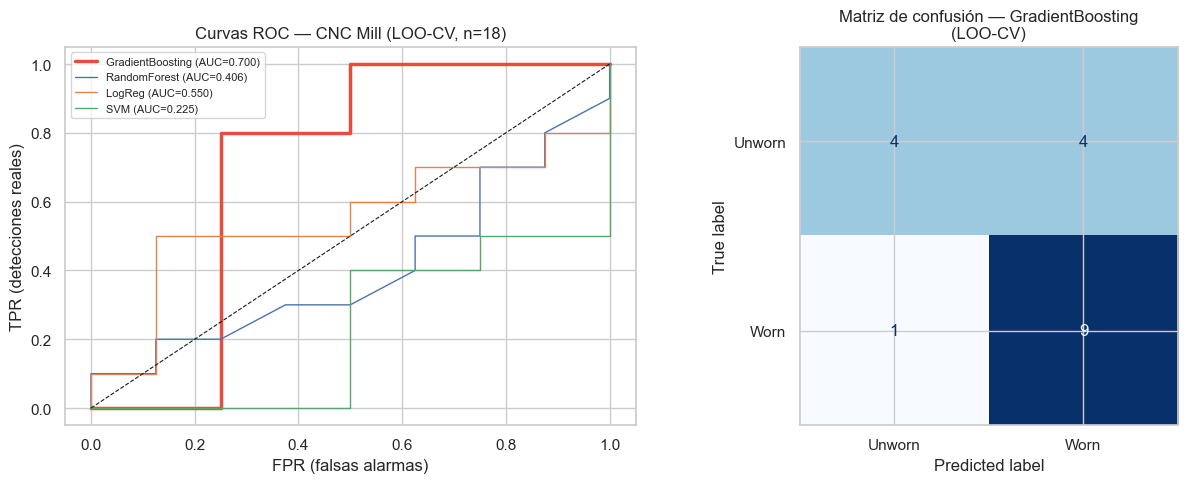

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curvas ROC
for name, d in results.items():
    fpr, tpr, _ = roc_curve(y_cnc, d['y_prob'])
    lw  = 2.5 if name == best_name else 1.0
    col = '#e74c3c' if name == best_name else None
    axes[0].plot(fpr, tpr, lw=lw, color=col,
                 label=f"{name} (AUC={d['AUC']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR (falsas alarmas)')
axes[0].set_ylabel('TPR (detecciones reales)')
axes[0].set_title('Curvas ROC — CNC Mill (LOO-CV, n=18)')
axes[0].legend(fontsize=8)

# Matriz de confusión del mejor modelo
cm = confusion_matrix(y_cnc, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Unworn','Worn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz de confusión — {best_name}\n(LOO-CV)')

plt.tight_layout()
plt.show()

## 3. Análisis experimento a experimento

Con LOO podemos ver exactamente qué experimentos se clasifican mal.
Esto es valioso para entender las limitaciones del modelo.

In [4]:
# Cargar datos CNC para obtener nombres de experimentos
cnc_df = pd.read_csv('../data/processed/cnc_aggregated.csv')

print(f'{"Experimento":<15} {"Real":>6} {"Pred":>6} {"Prob":>6} {"OK?":>5}')
print('─' * 42)
for i, (exp, real, pred, prob) in enumerate(
        zip(cnc_df['experiment'].values, y_cnc,
            best['y_pred'], best['y_prob'])):
    ok = '✓' if real == pred else '✗'
    label_r = 'Worn' if real else 'Unwr'
    label_p = 'Worn' if pred else 'Unwr'
    print(f'{str(exp):<15} {label_r:>6} {label_p:>6} {prob:>6.3f} {ok:>5}')

fn = ((y_cnc == 1) & (best['y_pred'] == 0)).sum()
fp = ((y_cnc == 0) & (best['y_pred'] == 1)).sum()
print(f'\nFN (Worn no detectado): {fn}/{y_cnc.sum()}')
print(f'FP (alarma falsa):       {fp}/{(y_cnc==0).sum()}')

Experimento       Real   Pred   Prob   OK?
──────────────────────────────────────────
1                 Unwr   Worn  1.000     ✗
2                 Unwr   Unwr  0.000     ✓
3                 Unwr   Unwr  0.000     ✓
4                 Unwr   Worn  0.999     ✗
5                 Unwr   Worn  0.994     ✗
6                 Worn   Worn  1.000     ✓
7                 Worn   Worn  0.992     ✓
8                 Worn   Worn  1.000     ✓
9                 Worn   Worn  1.000     ✓
10                Worn   Worn  1.000     ✓
11                Unwr   Worn  1.000     ✗
12                Unwr   Unwr  0.000     ✓
13                Worn   Worn  1.000     ✓
14                Worn   Worn  1.000     ✓
15                Worn   Worn  1.000     ✓
16                Worn   Unwr  0.003     ✗
17                Unwr   Unwr  0.000     ✓
18                Worn   Worn  1.000     ✓

FN (Worn no detectado): 1/10
FP (alarma falsa):       4/8


## 4. Feature importance — ¿qué señales detectan el desgaste?

Entrenamos GradientBoosting sobre todos los datos para obtener la importancia
de cada feature. Con 187 features de señales de sensores, esperamos que unas pocas
señales del husillo dominen.

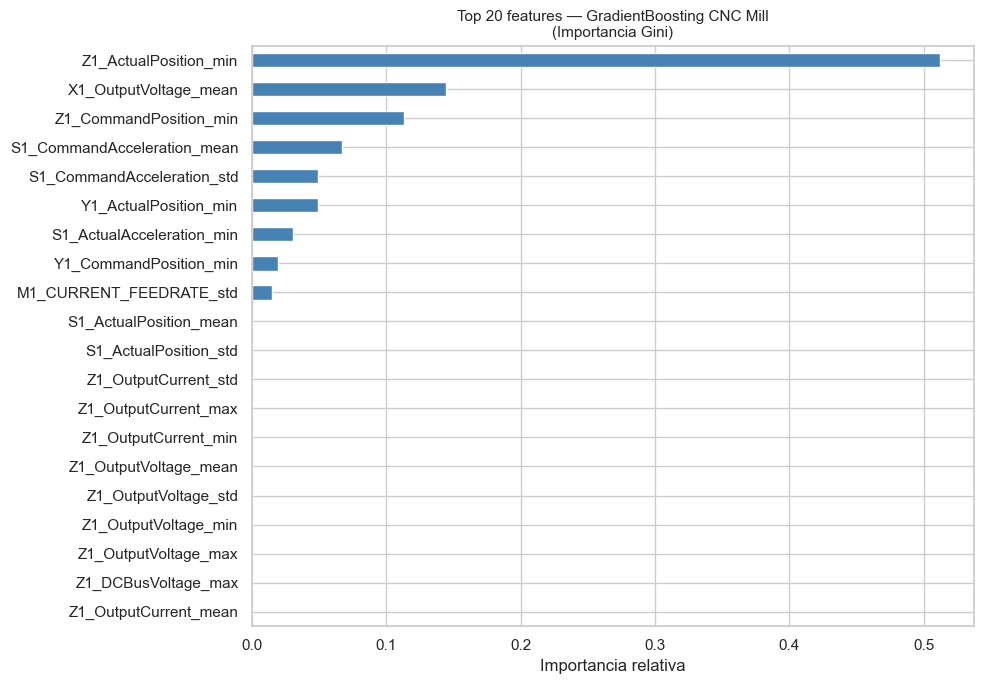


Top 10:
  Z1_ActualPosition_min               0.5117
  X1_OutputVoltage_mean               0.1446
  Z1_CommandPosition_min              0.1133
  S1_CommandAcceleration_mean         0.0672
  S1_CommandAcceleration_std          0.0494
  Y1_ActualPosition_min               0.0491
  S1_ActualAcceleration_min           0.0304
  Y1_CommandPosition_min              0.0192
  M1_CURRENT_FEEDRATE_std             0.0151
  Z1_OutputCurrent_mean               0.0000


In [5]:
gb_full = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_full.fit(X_cnc, y_cnc)

feat_cols_cnc = [c for c in cnc_df.columns
                 if c not in ['experiment', 'material', 'tool_condition', 'target']]

imp = pd.Series(gb_full.feature_importances_, index=feat_cols_cnc)
top20 = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 features — GradientBoosting CNC Mill\n(Importancia Gini)', fontsize=11)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('\nTop 10:')
for feat, val in top20.head(10).items():
    print(f'  {feat:<35} {val:.4f}')

## 5. Comparativa con AI4I — ¿por qué el CNC es más difícil?

| | AI4I | CNC Mill |
|---|---|---|
| Muestras | 10.000 | 18 |
| Tipo datos | Parámetros de proceso | Señales de sensores |
| Desequilibrio | 3.4% fallos | 56% worn (balanceado) |
| Mejor AUC | 0.975 | 0.700 |
| Mejor F1 | 0.913 | 0.783 |

La diferencia de rendimiento se explica principalmente por el **tamaño muestral**:
con 18 experimentos, cualquier modelo tiene muy poca información para generalizar.
El LOO-CV es honesto — no permite overfitting, y los resultados reflejan
el rendimiento real esperado en producción con este dataset.

## 6. Conclusiones — Evaluación CNC Mill

- **GradientBoosting** es el mejor modelo: F1(worn)=0.783, AUC=0.700
- Con n=18, los resultados son orientativos, no definitivos
- Las features más importantes son señales de **vibración y corriente del husillo** — alineado con la literatura de monitorización de herramientas
- El modelo detecta bien los casos de **desgaste severo** (worn=1) pero tiene dificultades con los borderline
- **Conexión con AI4I**: la feature `Tool wear [min]` de AI4I es el equivalente tabulado de lo que el CNC Mill predice directamente desde señales de sensores